# Synthetic evoked-response visualization workflow

This example builds a continuous recording with repeatable evoked responses, configures stimulus trials and baseline timing, and produces overview, focused, and customized Matplotlib figures.

**Prerequisites:** install `vneurotk[viz,notebook]`. Everything below is deterministic and offline. The `viz` module plots neural recordings; it does not run the DNN vision models provided by `vneurotk.vision`.

<a href="../viz.ipynb" download>Download this notebook</a>

## Synthesize a recording

The signal combines low-amplitude oscillations with a stimulus-locked Gaussian response. Two stimulus categories use different channel profiles, making their evoked activity visible without downloading data.

In [1]:
import numpy as np
from loguru import logger

import vneurotk as vtk

logger.remove()

sfreq = 100.0
n_samples = 700
times = np.arange(n_samples) / sfreq
onsets = np.array([120, 330, 540])
stim_ids = np.array(["face", "object", "face"])
channel_profiles = {
    "face": np.array([1.0, 0.7, 0.2, -0.3, -0.6, -0.2]),
    "object": np.array([0.2, 0.5, 1.0, 0.7, 0.1, -0.4]),
}

neuro = np.column_stack(
    [0.08 * np.sin(2 * np.pi * (2.0 + 0.35 * channel) * times + 0.3 * channel) for channel in range(6)]
)
for onset, stimulus in zip(onsets, stim_ids, strict=True):
    latency = (np.arange(n_samples) - onset) / sfreq
    response = np.exp(-0.5 * ((latency - 0.22) / 0.07) ** 2)
    neuro += response[:, None] * channel_profiles[stimulus][None, :]

recording = vtk.BaseData.for_continuous(
    neuro,
    neuro_info={
        "ch_names": ["O1", "Oz", "O2", "PO3", "POz", "PO4"],
        "sfreq": sfreq,
    },
)

## Configure stimuli and baseline

The integer trial window `[-20, 70]` spans 20 baseline samples before each onset and 70 samples after it. At 100 Hz, the derived baseline is −0.20 to 0 seconds and the full trial is −0.20 to 0.70 seconds.

In [2]:
recording.configure(
    stim_ids=stim_ids,
    vision_onsets=onsets,
    trial_window=[-20, 70],
)
recording.trial_info

{'baseline': [-20, 0], 'trial_window': [-20, 70]}

## Inspect the full experiment

Integer display bounds are sample indices. The overview includes all three configured trials.

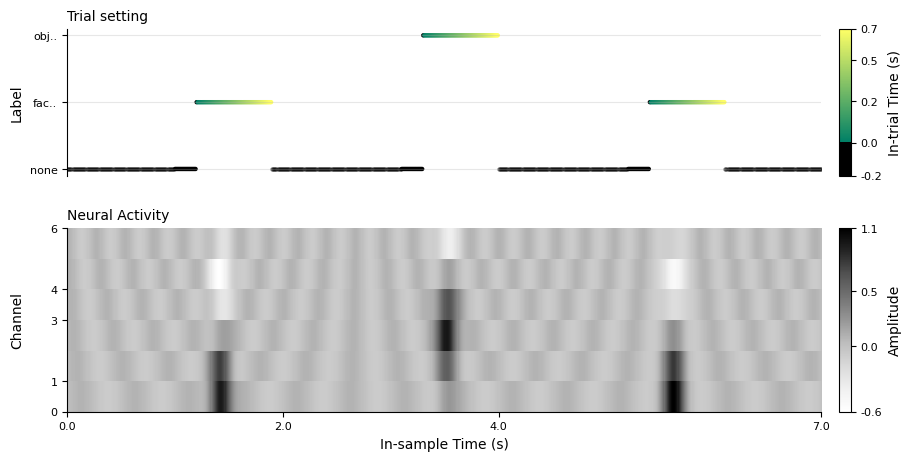

In [3]:
overview_figure = recording.plot(window=(0, 700), figsize=(9, 4.5))
overview_figure

## Focus on one evoked response

Non-integral float bounds are seconds. This 2.9–4.1 second view isolates the object trial while retaining its baseline and response.

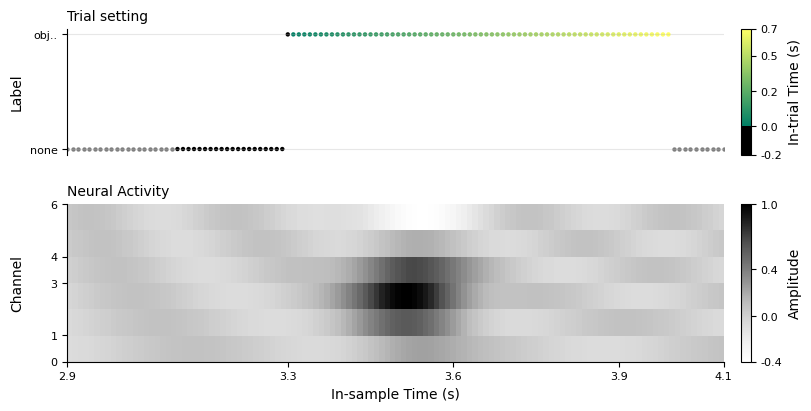

In [4]:
focused_figure = recording.plot(window=(2.9, 4.1), figsize=(8, 4))
focused_figure

## Customize and annotate the returned axes

`BaseData.plot` returns an ordinary Matplotlib figure. Pass plotting options through the method, then find the neural-activity axis and add domain-specific annotations. The figure remains caller-owned for further edits, saving, or closing.

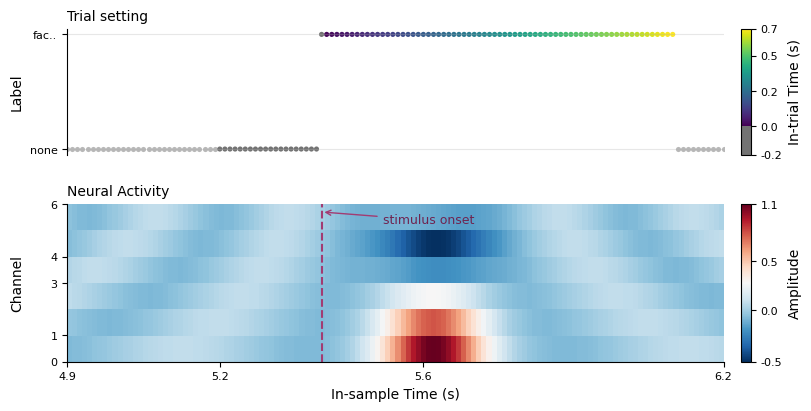

In [5]:
custom_figure = recording.plot(
    window=(4.9, 6.2),
    figsize=(8, 4),
    cmap_neuro="RdBu_r",
    cmap_ontime="viridis",
    color_offtime="0.45",
    marker_size=55,
)
neural_axis = next(axis for axis in custom_figure.axes if axis.get_title(loc="left") == "Neural Activity")
stimulus_time = onsets[-1] / sfreq
neural_axis.axvline(stimulus_time, color="#A23B72", linewidth=1.5, linestyle="--")
neural_axis.annotate(
    "stimulus onset",
    xy=(stimulus_time, 5.7),
    xytext=(stimulus_time + 0.12, 5.25),
    arrowprops={"arrowstyle": "->", "color": "#A23B72"},
    color="#6F2450",
    fontsize=9,
)
custom_figure

The overview establishes experiment structure, the focused view checks one trial in detail, and the custom view demonstrates Matplotlib-level extension without transferring figure ownership away from the caller.

## Related documentation

- [Visualization usage guide](../usage/viz.ipynb)
- [Neural-data example](data.ipynb)
- [Visualization API](../api/viz.md)
- [Core data API](../api/core.md)
